In [3]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.7/898.7 kB 25.0 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
from IPython.display import Image,display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="xKOCYeHOMRLrBcoaLlZy")
project = rf.workspace("skin-diseases-jzde4").project("skin-diseases-i30ay")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to skin-diseases-1 in yolov11:: 100%|██████████| 7868/7868 [00:01<00:00, 4913.54it/s]


In [6]:
!yolo task=detect mode=train model=yolo11s.pt data=/content/skin-diseases-1/data.yaml epochs=170 imgsz=640 plots=True




















100% 18.4M/18.4M [00:00<00:00, 242MB/s]
Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/skin-diseases-1/data.yaml, epochs=170, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fa

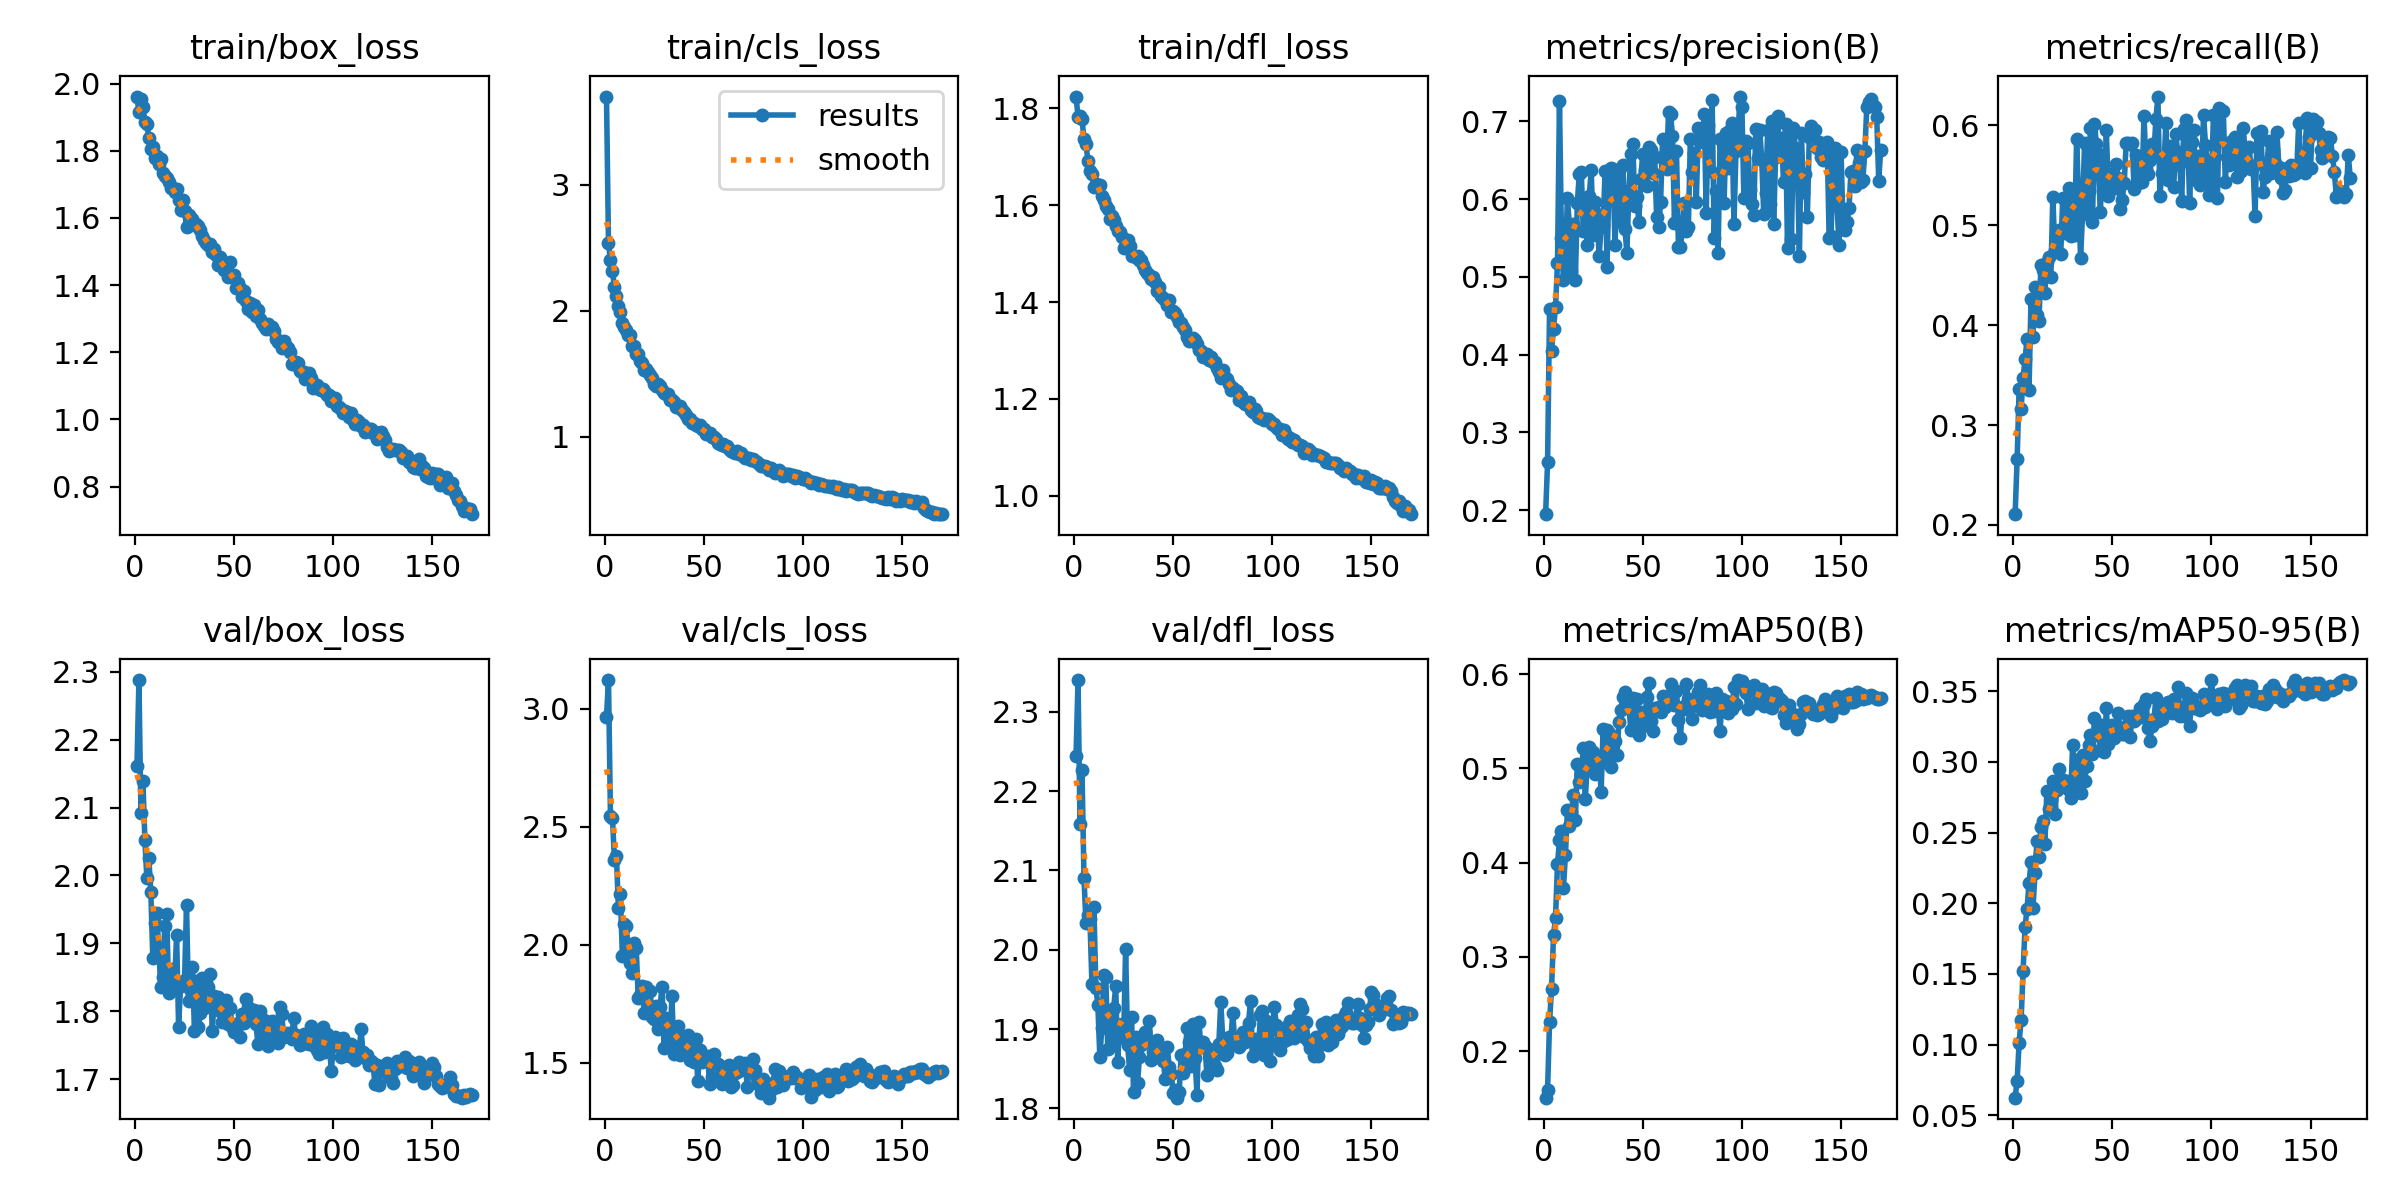

In [7]:
display(Image(filename='/content/runs/detect/train/results.png', width=600))

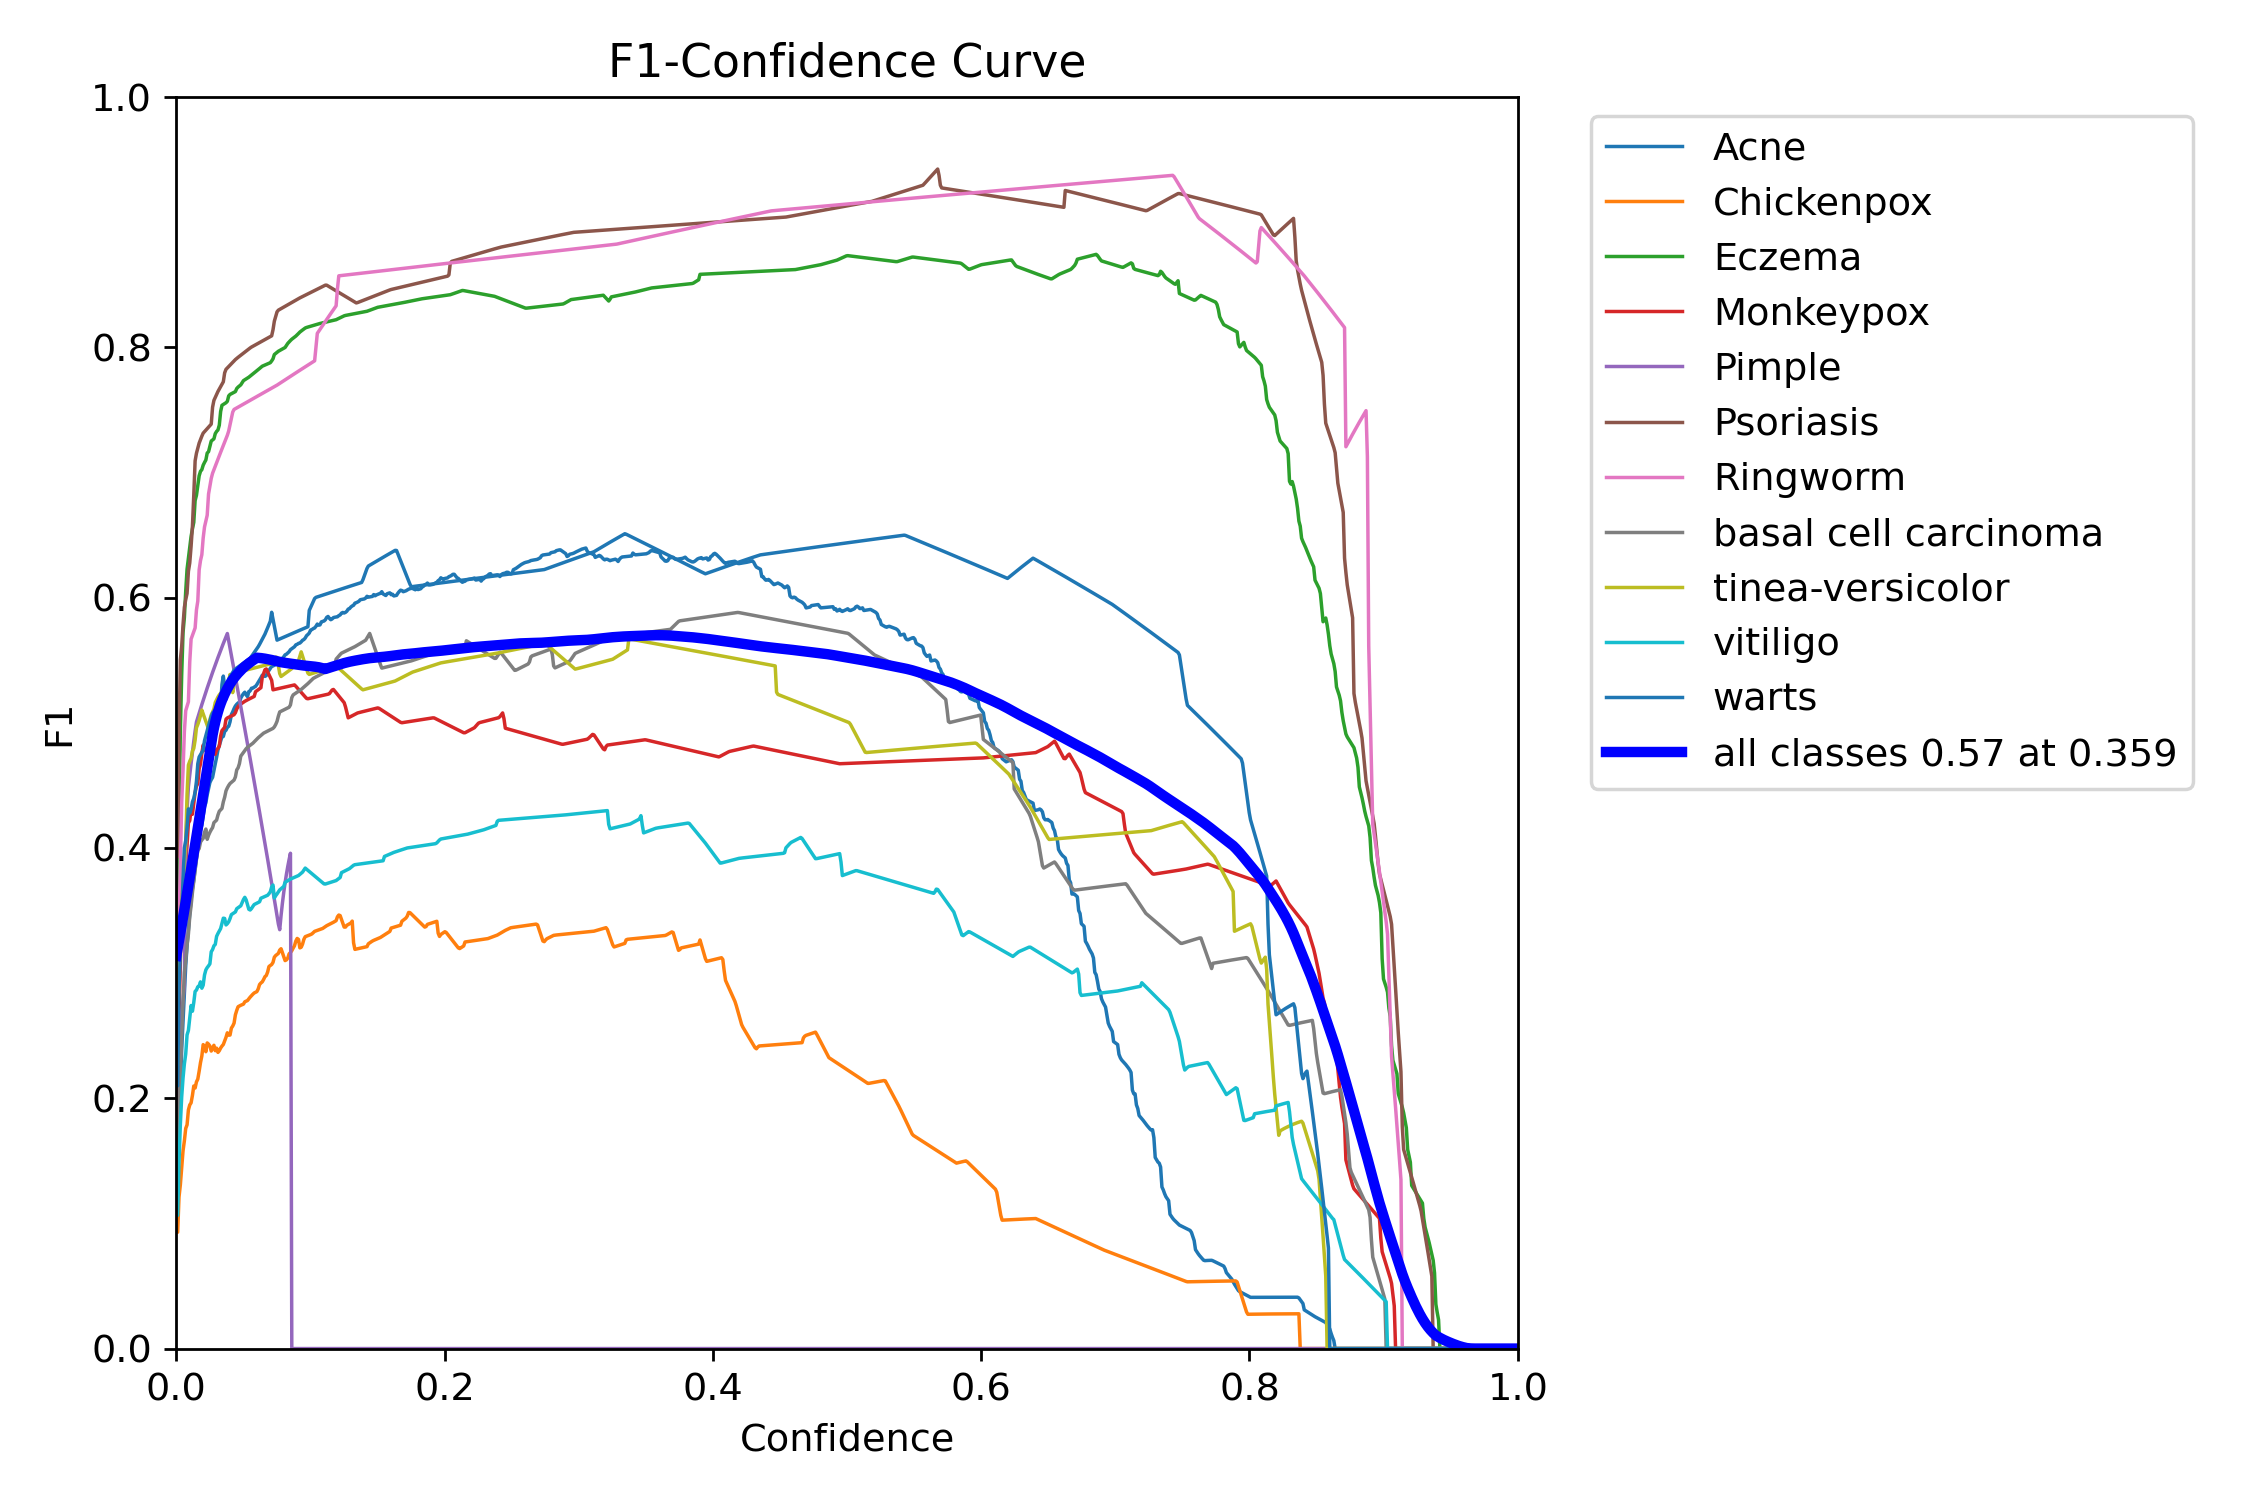

In [8]:
display(Image(filename='/content/runs/detect/train/F1_curve.png', width=600))

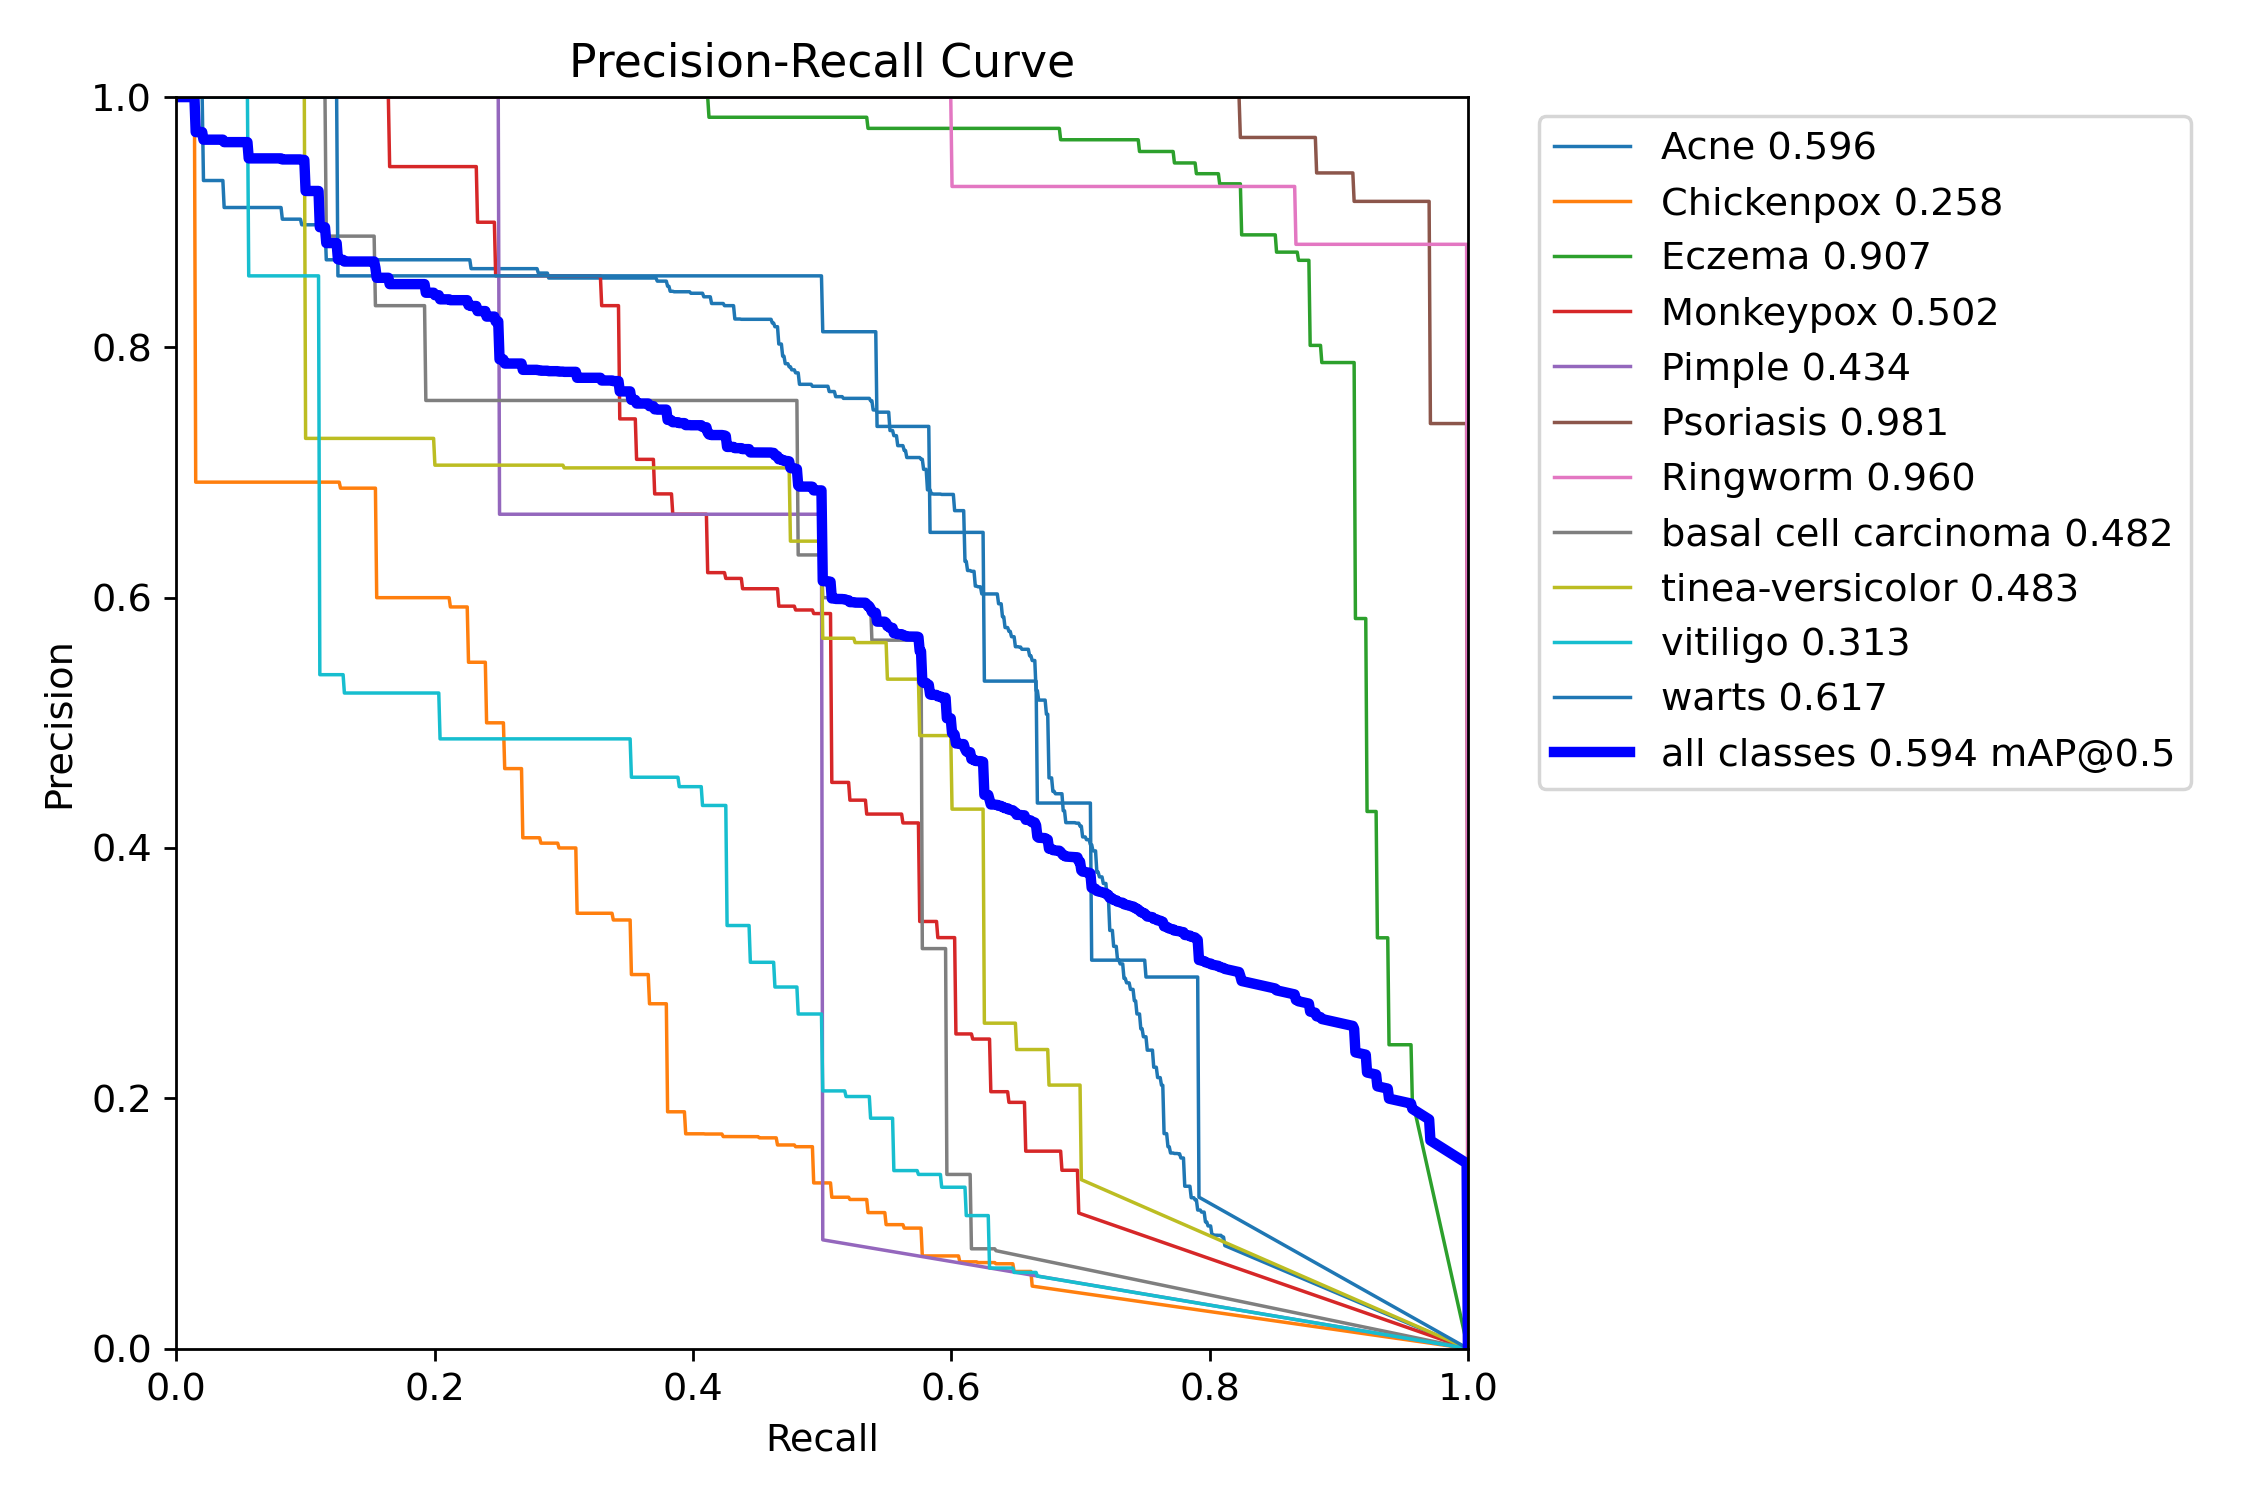

In [9]:
display(Image(filename='/content/runs/detect/train/PR_curve.png', width=600))

In [10]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/skin-diseases-1/data.yaml

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/skin-diseases-1/valid/labels.cache... 264 images, 0 backgrounds, 0 corrupt: 100% 264/264 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 175, len(boxes) = 863. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 17/17 [00:05<00:00,  3.34it/s]
                   all        264        863       0.72       0.54      0.594      0.358
                  Acne         27        382        0.7      0.579      0.596      0.227
            Chickenpox         21         71      0.523      0.239      0.261      0.101
                Eczema         36       

In [12]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.35 source=/content/skin-diseases-1/test/images save=True

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs

image 1/193 /content/skin-diseases-1/test/images/3_12_jpg.rf.8888b7e46ead73fdca6f4c86517bd107.jpg: 640x640 (no detections), 15.6ms
image 2/193 /content/skin-diseases-1/test/images/6_70_jpg.rf.18736b4eb5f756eafe325f3d3633cbe9.jpg: 640x640 5 Ringworms, 15.6ms
image 3/193 /content/skin-diseases-1/test/images/7_3_jpg.rf.60ae5e39726668f0cfce26f20c0d16f1.jpg: 640x640 1 Ringworm, 15.7ms
image 4/193 /content/skin-diseases-1/test/images/800px-Yeartinfection-Copy_jpg.rf.a9311549ad818844d084e5221d538cd2.jpg: 640x640 1 Ringworm, 15.6ms
image 5/193 /content/skin-diseases-1/test/images/CHP_03_01_jpg.rf.578f1344bbda97e4ed6e76f417c185d7.jpg: 640x640 3 Chickenpoxs, 15.6ms
image 6/193 /content/skin-diseases-1/test/images/CHP_06_01_jpg.rf.b9148e902f5e11589f702f3d75a00665.jpg: 640x640 1 Chickenpox, 15.6ms
image 7/193 /content/skin-diseases-1

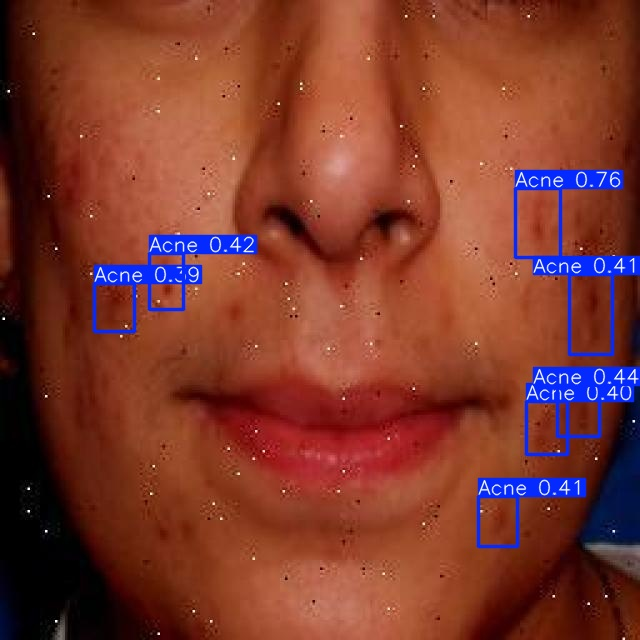

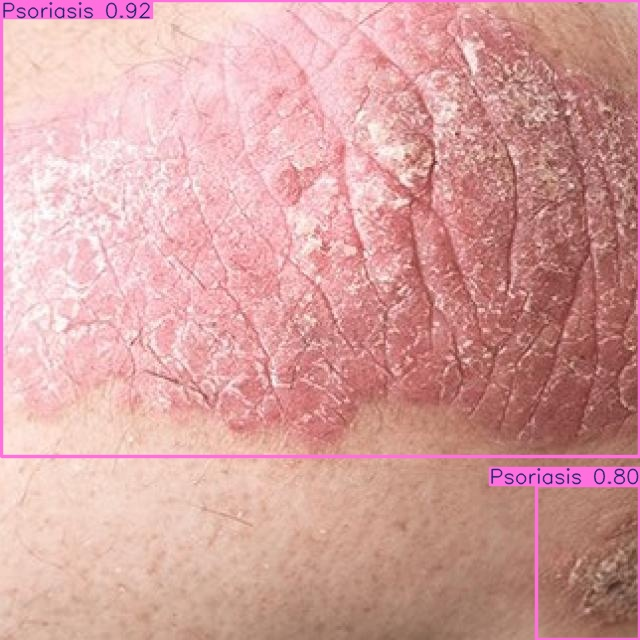

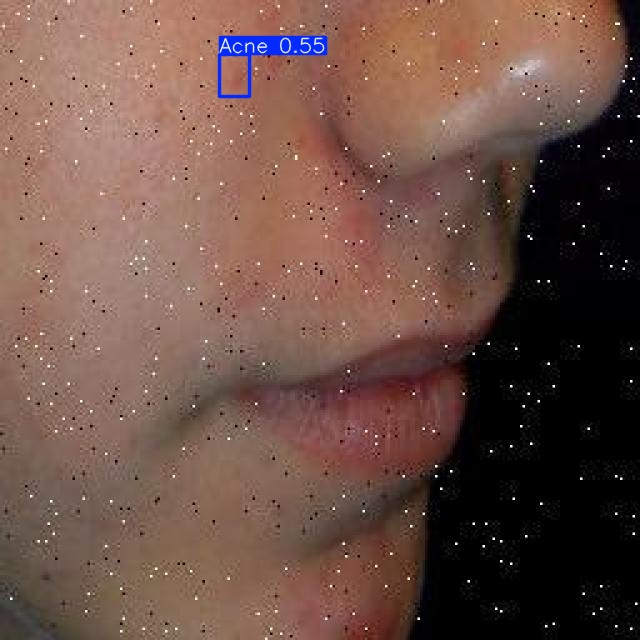

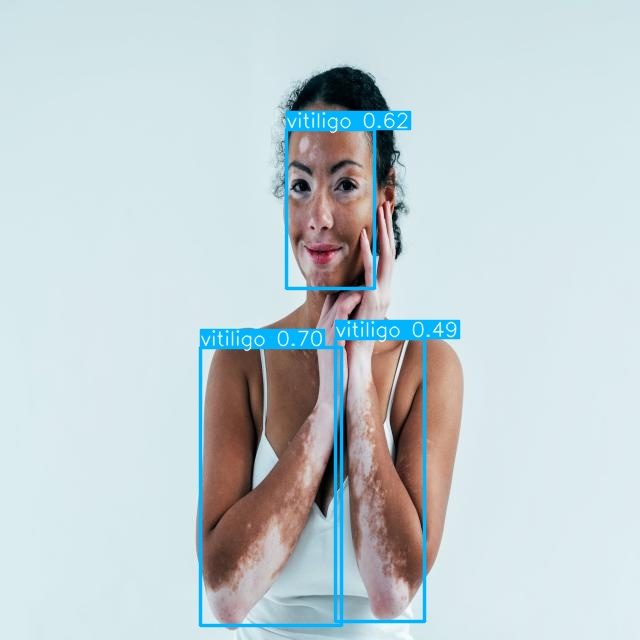

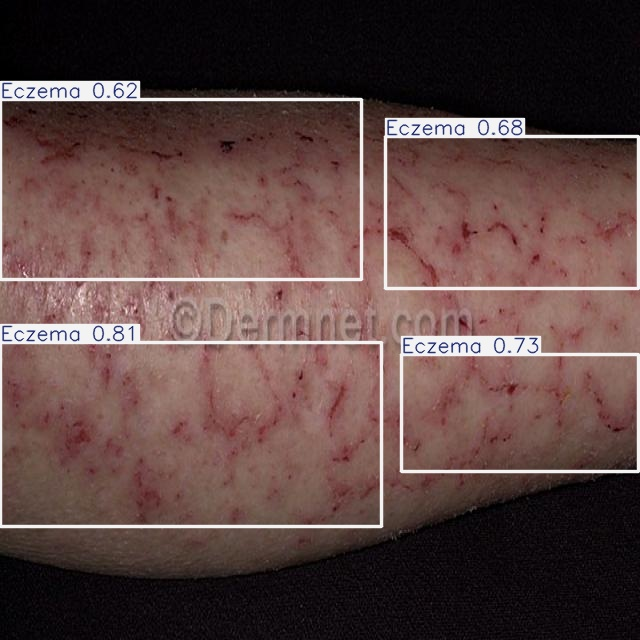

In [13]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:5]:
    display(IPyImage(filename=img, width=600))
    print("\n")